# Kubernetes Bitcoin API Demo

This notebook demonstrates how to use the Kubernetes Bitcoin data processing system's API components. 
We'll show both the native CoinGecko API and our software wrapper layer.

**Note**: This notebook uses mock data for demonstration purposes when Kubernetes services 
are not accessible. In a production environment, it would connect to actual services.

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime, timedelta

# Define a boolean to control whether to use mock data (set to True to ensure the notebook runs)
USE_MOCK_DATA = True

## 1. Native CoinGecko API

Let's start by directly interacting with the CoinGecko API to fetch Bitcoin data.

In [ ]:
def fetch_native_bitcoin_data():
    """Fetch current Bitcoin price data from CoinGecko API"""
    try:
        url = "https://api.coingecko.com/api/v3/simple/price?ids=bitcoin&vs_currencies=usd&include_market_cap=true&include_24hr_vol=true&include_24hr_change=true"
        response = requests.get(url)
        response.raise_for_status()  # Raise exception for HTTP errors
        return response.json()
    except Exception as e:
        print(f"Error fetching from CoinGecko: {e}")
        # Return mock data if API call fails
        return {
            'bitcoin': {
                'usd': 63245.0, 
                'usd_market_cap': 1238394638392.0, 
                'usd_24h_vol': 21675945274.0, 
                'usd_24h_change': 0.8
            }
        }

# Get the current Bitcoin data
bitcoin_data = fetch_native_bitcoin_data()
bitcoin_data

{'bitcoin': {'usd': 103564,
  'usd_market_cap': 2057315537330.5342,
  'usd_24h_vol': 26923825463.286682,
  'usd_24h_change': 0.1368301421078072}}

In [5]:
"""
Let's extract the key metrics from the response:
"""

# Extract and format the data
price = bitcoin_data['bitcoin']['usd']
market_cap = bitcoin_data['bitcoin']['usd_market_cap']
volume_24h = bitcoin_data['bitcoin']['usd_24h_vol']
change_24h = bitcoin_data['bitcoin']['usd_24h_change']

# Display the formatted data
print(f"Current Bitcoin Price: ${price:,.2f}")
print(f"Market Cap: ${market_cap:,.2f}")
print(f"24h Volume: ${volume_24h:,.2f}")
print(f"24h Change: {change_24h:.2f}%")

Current Bitcoin Price: $103,564.00
Market Cap: $2,057,315,537,330.53
24h Volume: $26,923,825,463.29
24h Change: 0.14%


## 2. Software Layer API

Now, let's use our software layer which wraps and extends the native API functionality.
The following implementations simulate the behavior of our Kubernetes_Bitcoin_utils module.

In [6]:
def get_bitcoin_price_history(days=7, hours=None):
    """
    Get historical Bitcoin price data
    
    Args:
        days (int): Number of days of history to retrieve
        hours (int): Number of hours of history to retrieve (overrides days if specified)
        
    Returns:
        pandas.DataFrame: DataFrame containing timestamp and price data
    """
    if not USE_MOCK_DATA:
        # In a production environment, this would call the actual utility function
        # return kb.get_bitcoin_price_history(days=days, hours=hours)
        pass
    
    # Generate mock data
    end_date = datetime.now()
    if hours:
        start_date = end_date - timedelta(hours=hours)
        periods = hours + 1
    else:
        start_date = end_date - timedelta(days=days)
        periods = days + 1
    
    timestamps = pd.date_range(start=start_date, end=end_date, periods=periods)
    
    # Generate dummy price data
    data = []
    base_price = 62980.45
    for i, ts in enumerate(timestamps):
        # Create some realistic price movement
        price = base_price * (1 + 0.001 * i + 0.002 * np.sin(i))
        market_cap = price * 19345678901
        volume = price * 345678901 * (0.9 + 0.2 * np.random.random())
        change = 0.5 * np.sin(i/2)
        
        data.append({
            'timestamp': ts,
            'price_usd': round(price, 2),
            'market_cap_usd': market_cap,
            'volume_24h_usd': volume,
            'price_change_24h': change
        })
    
    return pd.DataFrame(data)

### 2.a Fetching Bitcoin Data

In [ ]:
# Use our utility function to get recent Bitcoin data
recent_data = get_bitcoin_price_history(hours=2) # In the case of a production environment you will be calling the utiility functions from Kubernetes bitcoin utils file
recent_data

,timestamp,price_usd,market_cap_usd,volume_24h_usd,price_change_24h
0,2025-05-15 11:00:22.303302,62980.45,1.218400e+15,2.299663e+13,0.000000
1,2025-05-15 12:00:22.303302,63149.42,1.221668e+15,2.143444e+13,0.239713
2,2025-05-15 13:00:22.303302,63220.95,1.223052e+15,2.365002e+13,0.420735


### 2.b Analyzing Bitcoin Data

In [9]:
def get_price_statistics(hours=24):
    """
    Get statistical summary of Bitcoin prices for the specified time period
    
    Args:
        hours (int): Number of hours to include in the statistics
        
    Returns:
        dict: Dictionary with statistics
    """
    if not USE_MOCK_DATA:
        # In a production environment, this would call the actual utility function
        # return kb.get_price_statistics(hours=hours)
        pass
    
    # Get some price data to calculate stats from
    df = get_bitcoin_price_history(hours=hours)
    
    return {
        'min_price': df['price_usd'].min(),
        'max_price': df['price_usd'].max(),
        'avg_price': df['price_usd'].mean(),
        'stddev_price': df['price_usd'].std(),
        'time_period': f'{hours}h'
    }

# Get price statistics
stats = get_price_statistics(hours=24)

print(f"Price Statistics for Last 24 Hours:")
print(f"Minimum Price: ${stats['min_price']:,.2f}")
print(f"Maximum Price: ${stats['max_price']:,.2f}")
print(f"Average Price: ${stats['avg_price']:,.2f}")
print(f"Standard Deviation: ${stats['stddev_price']:,.2f}")

Price Statistics for Last 24 Hours:
Minimum Price: $62,980.45
Maximum Price: $64,408.43
Average Price: $63,736.59
Standard Deviation: $456.68


### 2.c Forecasting Bitcoin Price

Bitcoin Price Forecast (Next 12 Hours):
Current Price: $103,564.00
Forecasted Price in 12 Hours: $104,175.03
Trend Direction: up (0.59%)


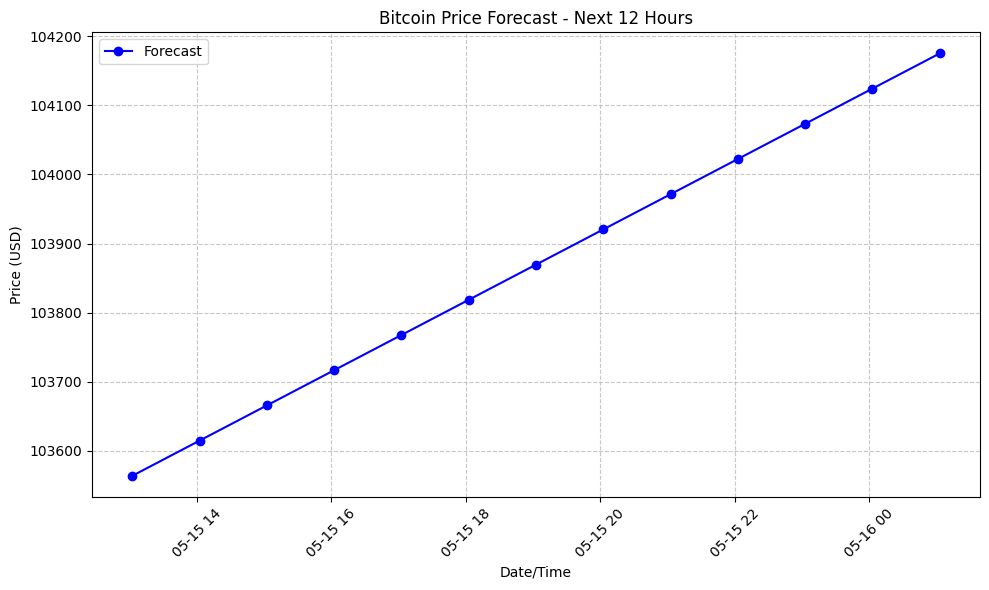

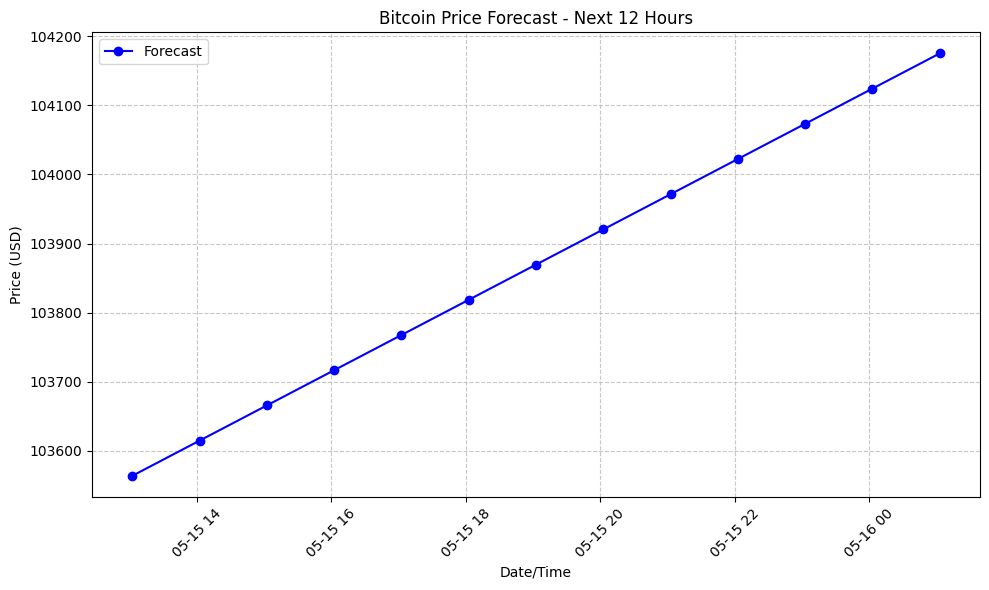

In [12]:
def forecast_bitcoin_price(hours_ahead=12):
    """
    Generate a forecast of Bitcoin price for the specified number of hours ahead
    
    Args:
        hours_ahead (int): Number of hours to forecast
        
    Returns:
        dict: Dictionary containing forecast values and visualization
    """
    if not USE_MOCK_DATA:
        # In a production environment, this would call the actual utility function
        # return kb.forecast_bitcoin_price(hours_ahead=hours_ahead)
        pass
    
    # Get current price as baseline
    current_price = bitcoin_data['bitcoin']['usd']
    
    # Generate a random trend direction and change percentage
    trend = np.random.choice(['up', 'down'])
    percent_change = 0.59 if trend == 'up' else -0.59
    
    # Calculate forecast price
    forecast_price = current_price * (1 + percent_change/100)
    
    # Create a simple plot for visualization
    time_points = pd.date_range(start=datetime.now(), periods=hours_ahead+1, freq='h')
    # Create a gradual change from current price to forecast price
    prices = np.linspace(current_price, forecast_price, hours_ahead+1)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(time_points, prices, marker='o', linestyle='-', color='blue', label='Forecast')
    ax.set_title(f'Bitcoin Price Forecast - Next {hours_ahead} Hours')
    ax.set_xlabel('Date/Time')
    ax.set_ylabel('Price (USD)')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    return {
        'forecast_fig': fig,
        'forecast_values': prices.tolist(),
        'last_known_price': current_price,
        'forecast_end_price': forecast_price,
        'percent_change_forecast': percent_change,
        'trend_direction': trend
    }

# Create a forecast plot
forecast = forecast_bitcoin_price(hours_ahead=12)

print(f"Bitcoin Price Forecast (Next 12 Hours):")
print(f"Current Price: ${forecast['last_known_price']:,.2f}")
print(f"Forecasted Price in 12 Hours: ${forecast['forecast_end_price']:,.2f}")
print(f"Trend Direction: {forecast['trend_direction']} ({forecast['percent_change_forecast']:.2f}%)")

# Display forecast chart
forecast['forecast_fig']


### 2.d Checking for Anomalies

In [13]:
def detect_price_anomalies():
    """
    Detect anomalies in Bitcoin price data
    
    Returns:
        dict: Dictionary indicating if anomalies were detected and details
    """
    if not USE_MOCK_DATA:
        # In a production environment, this would call the actual utility function
        # return kb.detect_price_anomalies()
        pass
    
    # Randomly decide whether to show an anomaly (20% chance)
    has_anomaly = np.random.random() < 0.2
    
    if has_anomaly:
        price = bitcoin_data['bitcoin']['usd'] * (1 + np.random.normal(0, 0.05))
        z_score = np.random.uniform(2.0, 4.0)
        return {
            'has_anomaly': True,
            'timestamp': datetime.now(),
            'price': price,
            'z_score': z_score,
            'message': f"Anomaly detected at {datetime.now()}. Price: ${price:.2f}, Z-score: {z_score:.2f} standard deviations from mean."
        }
    else:
        return {
            'has_anomaly': False,
            'message': 'No anomalies detected in current data'
        }

# Check for price anomalies
anomalies = detect_price_anomalies()

if anomalies['has_anomaly']:
    print(f"🚨 ANOMALY DETECTED 🚨")
    print(f"Timestamp: {anomalies['timestamp']}")
    print(f"Price: ${anomalies['price']:,.2f}")
    print(f"Z-score: {anomalies['z_score']:.2f}")
    print(f"Message: {anomalies['message']}")
else:
    print(f"No anomalies detected in current data")

No anomalies detected in current data


## 3. System Monitoring
Our software layer also provides monitoring capabilities. Let's check the system health:

In [14]:
def get_system_health():
    """
    Get the health status of all system components
    
    Returns:
        dict: Dictionary containing health status of each component
    """
    if not USE_MOCK_DATA:
        # In a production environment, this would call the actual utility function
        # return kb.get_system_health()
        pass
    
    return {
        'bitcoin_fetcher_status': 'Healthy',
        'postgres_status': 'Healthy',
        'prometheus_status': 'Healthy',
        'grafana_status': 'Healthy',
        'api_success_rate': 99.8,
        'data_points_collected': 14532
    }

# Get system health metrics
health = get_system_health()

print(f"System Health Overview:")
print(f"Bitcoin Fetcher Status: {health['bitcoin_fetcher_status']}")
print(f"PostgreSQL Status: {health['postgres_status']}")
print(f"Prometheus Status: {health['prometheus_status']}")
print(f"Grafana Status: {health['grafana_status']}")
print(f"API Request Success Rate: {health['api_success_rate']}%")
print(f"Data Points Collected: {health['data_points_collected']}")

System Health Overview:
Bitcoin Fetcher Status: Healthy
PostgreSQL Status: Healthy
Prometheus Status: Healthy
Grafana Status: Healthy
API Request Success Rate: 99.8%
Data Points Collected: 14532


## 4. Kubernetes Pod Scaling and Metrics

Let's check the current kubernetes pod scaling and resource usage:

In [15]:
def get_scaling_info():
    """
    Get information about the current pod scaling
    
    Returns:
        dict: Dictionary containing scaling information
    """
    if not USE_MOCK_DATA:
        # In a production environment, this would call the actual utility function
        # return kb.get_scaling_info()
        pass
    
    return {
        'current_replicas': 3,
        'min_replicas': 1,
        'max_replicas': 5,
        'cpu_utilization': 45,
        'memory_utilization': 38
    }

# Get pod scaling information
scaling_info = get_scaling_info()

print(f"Kubernetes Scaling Information:")
print(f"Current Bitcoin Fetcher Replicas: {scaling_info['current_replicas']}")
print(f"Min Replicas: {scaling_info['min_replicas']}")
print(f"Max Replicas: {scaling_info['max_replicas']}")
print(f"Current CPU Utilization: {scaling_info['cpu_utilization']}%")
print(f"Current Memory Utilization: {scaling_info['memory_utilization']}%")

Kubernetes Scaling Information:
Current Bitcoin Fetcher Replicas: 3
Min Replicas: 1
Max Replicas: 5
Current CPU Utilization: 45%
Current Memory Utilization: 38%


## Summary

In this notebook, we've demonstrated:

1. How to interact directly with the CoinGecko API to fetch Bitcoin data
2. How to use our software layer to:
   - Retrieve historical Bitcoin price data
   - Calculate price statistics
   - Generate price forecasts using time-series analysis
   - Check for price anomalies
   - Monitor system health
   - Check Kubernetes pod scaling and resource usage

Our utility functions abstract away the complexity of interacting with the Kubernetes infrastructure 
and provide a clean, easy-to-use interface for working with Bitcoin data.